# NuFuse Pipeline — Python Bindings Demo

This notebook demonstrates the pybind11 Python bindings for the NuFuse multi-sensor SLAM pipeline.
You can run ablation studies, build results tables, and visualize trajectories — all from Python.

**New robustification features:** GNC optimizer, Cauchy robust kernels, LiDAR quality gating, IMU-consistency checks.

In [1]:
import sys
sys.path.insert(0, '..')  # Ensure nufuse package is importable

import nufuse
from nufuse import OptimizerType, RobustKernel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print(f"nufuse bindings loaded: {dir(nufuse)}")
print(f"Default config: {nufuse.PipelineConfig()}")

nufuse bindings loaded: ['ErrorMetrics', 'GncConfig', 'LidarConfig', 'OptimizedPose', 'OptimizedResults', 'OptimizerType', 'PipelineConfig', 'PipelineResult', 'RadarConfig', 'RobustKernel', 'SceneInfo', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_nufuse', 'load_config', 'run_batch', 'run_pipeline']
Default config: PipelineConfig(gps=1, lidar=1, radar=1, nhc=1, fwdvel=1, gps_max=0, optimizer=LM, kernel=Cauchy)


## 1. Single Scene Pipeline Run

Run the pipeline on a single scene with a custom configuration.

In [2]:
MCAP_DIR = Path("/workspace/data/nuscenes/mcap")
scenes = sorted(MCAP_DIR.glob("*.mcap"))
print(f"Available scenes: {len(scenes)}")
for s in scenes:
    print(f"  {s.name}")

Available scenes: 10
  NuScenes-v1.0-mini-scene-0061.mcap
  NuScenes-v1.0-mini-scene-0103.mcap
  NuScenes-v1.0-mini-scene-0553.mcap
  NuScenes-v1.0-mini-scene-0655.mcap
  NuScenes-v1.0-mini-scene-0757.mcap
  NuScenes-v1.0-mini-scene-0796.mcap
  NuScenes-v1.0-mini-scene-0916.mcap
  NuScenes-v1.0-mini-scene-1077.mcap
  NuScenes-v1.0-mini-scene-1094.mcap
  NuScenes-v1.0-mini-scene-1100.mcap


In [3]:
# Run with IMU + NHC + FwdVel only (dead-reckoning, C1 config)
cfg = nufuse.PipelineConfig()
cfg.enable_gps = False
cfg.enable_lidar = False
cfg.enable_radar = False

result = nufuse.run_pipeline(str(scenes[4]), cfg, init_from_gt=True)  # scene-0757

print(f"Scene info: IMU={result.scene_info.num_imu}, GNSS={result.scene_info.num_gnss}, "
      f"Odom={result.scene_info.num_odom}, LiDAR={result.scene_info.num_lidar}")
print(f"Keyframes: {result.results.num_keyframes}")
print(f"End-position error: {result.error.norm_error:.2f} m")
print(f"Odom scale: {result.results.odom_scale:.4f}")
print(f"Final gyro bias: {result.results.final_bias_gyro}")

Scene info: IMU=1980, GNSS=41, Odom=991, LiDAR=397
Keyframes: 39
End-position error: 0.92 m
Odom scale: 0.9968
Final gyro bias: [0.00014691 0.00050602 0.00033149]


## 2. Trajectory Visualization

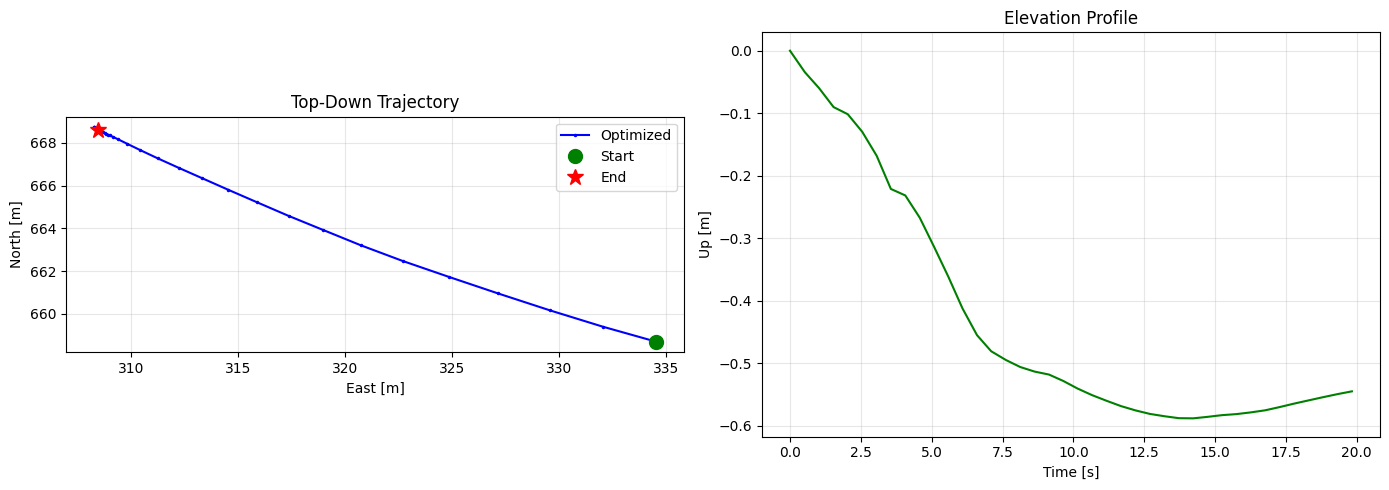

In [4]:
# Extract ENU trajectory
positions = np.array([p.translation for p in result.results.poses])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top-down view (East-North)
axes[0].plot(positions[:, 0], positions[:, 1], 'b.-', markersize=3, label='Optimized')
axes[0].plot(positions[0, 0], positions[0, 1], 'go', markersize=10, label='Start')
axes[0].plot(positions[-1, 0], positions[-1, 1], 'r*', markersize=12, label='End')
axes[0].set_xlabel('East [m]')
axes[0].set_ylabel('North [m]')
axes[0].set_title('Top-Down Trajectory')
axes[0].legend()
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# Elevation profile
timestamps_s = np.array([p.stamp_ns for p in result.results.poses]) * 1e-9
timestamps_s -= timestamps_s[0]
axes[1].plot(timestamps_s, positions[:, 2], 'g-')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Up [m]')
axes[1].set_title('Elevation Profile')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Ablation Study — Build Results Table

Reproduce the README results table by running all configurations across all scenes.

In [5]:
# Define configurations matching the README
def make_configs():
    """Create the 7 configurations from the README.
    All configs use GNC-LM optimizer + Cauchy kernel by default (compiled defaults).
    """
    configs = {}

    # C1: IMU + NHC + FwdVel (GT init)
    c1 = nufuse.PipelineConfig()
    c1.enable_gps = False
    c1.enable_lidar = False
    c1.enable_radar = False
    configs['C1'] = (c1, True)  # (config, init_from_gt)

    # C2: GPS(3) + IMU + NHC + FwdVel
    c2 = nufuse.PipelineConfig()
    c2.enable_lidar = False
    c2.enable_radar = False
    c2.gps_max_measurements = 3
    configs['C2'] = (c2, False)

    # C3: GPS(3) + IMU + LiDAR + NHC + FwdVel
    c3 = nufuse.PipelineConfig()
    c3.enable_radar = False
    c3.gps_max_measurements = 3
    configs['C3'] = (c3, False)

    # C4: GPS(3) + IMU + Radar + NHC + FwdVel
    c4 = nufuse.PipelineConfig()
    c4.enable_lidar = False
    c4.gps_max_measurements = 3
    configs['C4'] = (c4, False)

    # C5: GPS(3) + IMU + LiDAR + NHC (no FwdVel)
    c5 = nufuse.PipelineConfig()
    c5.enable_radar = False
    c5.enable_fwdvel = False
    c5.gps_max_measurements = 3
    configs['C5'] = (c5, False)

    # C6: GPS(3) + IMU + Radar + NHC (no FwdVel)
    c6 = nufuse.PipelineConfig()
    c6.enable_lidar = False
    c6.enable_fwdvel = False
    c6.gps_max_measurements = 3
    configs['C6'] = (c6, False)

    # C7: Full (all sensors)
    c7 = nufuse.PipelineConfig()
    c7.gps_max_measurements = 3
    configs['C7'] = (c7, False)

    return configs

configs = make_configs()
print("Configurations defined (all use GNC-LM + Cauchy by default):")
for name, (cfg, gt) in configs.items():
    print(f"  {name}: {cfg}, init_from_gt={gt}")

Configurations defined (all use GNC-LM + Cauchy by default):
  C1: PipelineConfig(gps=0, lidar=0, radar=0, nhc=1, fwdvel=1, gps_max=0, optimizer=LM, kernel=Cauchy), init_from_gt=True
  C2: PipelineConfig(gps=1, lidar=0, radar=0, nhc=1, fwdvel=1, gps_max=3, optimizer=LM, kernel=Cauchy), init_from_gt=False
  C3: PipelineConfig(gps=1, lidar=1, radar=0, nhc=1, fwdvel=1, gps_max=3, optimizer=LM, kernel=Cauchy), init_from_gt=False
  C4: PipelineConfig(gps=1, lidar=0, radar=1, nhc=1, fwdvel=1, gps_max=3, optimizer=LM, kernel=Cauchy), init_from_gt=False
  C5: PipelineConfig(gps=1, lidar=1, radar=0, nhc=1, fwdvel=0, gps_max=3, optimizer=LM, kernel=Cauchy), init_from_gt=False
  C6: PipelineConfig(gps=1, lidar=0, radar=1, nhc=1, fwdvel=0, gps_max=3, optimizer=LM, kernel=Cauchy), init_from_gt=False
  C7: PipelineConfig(gps=1, lidar=1, radar=1, nhc=1, fwdvel=1, gps_max=3, optimizer=LM, kernel=Cauchy), init_from_gt=False


In [6]:
# Run all configurations across all scenes
results_table = {}

for scene_path in scenes:
    scene_id = scene_path.stem.split('-')[-1]  # e.g. "0757"
    results_table[scene_id] = {}

    for cfg_name, (cfg, init_gt) in configs.items():
        try:
            r = nufuse.run_pipeline(str(scene_path), cfg, init_from_gt=init_gt)
            results_table[scene_id][cfg_name] = round(r.error.norm_error, 1)
        except Exception as e:
            results_table[scene_id][cfg_name] = None  # crash / insufficient data
            print(f"  [{scene_id}/{cfg_name}] Failed: {e}")

    print(f"  Scene {scene_id} done")

print("\nAll runs complete!")

  Scene 0061 done
  Scene 0103 done
  Scene 0553 done
  Scene 0655 done
  Scene 0757 done
  Scene 0796 done
  Scene 0916 done
  [1077/C2] Failed: unordered_map::at
  [1077/C4] Failed: unordered_map::at
  [1077/C6] Failed: unordered_map::at
  Scene 1077 done
  Scene 1094 done
  Scene 1100 done

All runs complete!


In [7]:
# Build the results DataFrame (same format as README)
df = pd.DataFrame.from_dict(results_table, orient='index')
df.index.name = 'Scene'
df = df[['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']]  # ensure column order

# Format: replace None with "—"
df_display = df.fillna('—')

print("\n" + "="*70)
print("End-Position Error (m) — NuScenes Mini")
print("="*70)
print(df_display.to_markdown())
print("\nConfiguration Key:")
print("  C1: IMU + NHC + FwdVel (GT init)")
print("  C2: GPS(3) + IMU + NHC + FwdVel")
print("  C3: GPS(3) + IMU + LiDAR + NHC + FwdVel")
print("  C4: GPS(3) + IMU + Radar + NHC + FwdVel")
print("  C5: GPS(3) + IMU + LiDAR + NHC")
print("  C6: GPS(3) + IMU + Radar + NHC")
print("  C7: Full (all sensors)")


End-Position Error (m) — NuScenes Mini
|   Scene |   C1 | C2   |   C3 | C4   |    C5 | C6   |   C7 |
|--------:|-----:|:-----|-----:|:-----|------:|:-----|-----:|
|    0061 |  1.5 | 1.6  |  1.9 | 1.5  |   6.7 | 2.8  |  2.3 |
|    0103 |  4.7 | 4.6  |  7.1 | 4.7  |   5.6 | 7.0  |  7.4 |
|    0553 |  0   | 0.0  |  0.1 | 0.0  |   1.2 | 10.6 |  0.1 |
|    0655 |  3.8 | 4.0  | 14.3 | 4.0  |  32.1 | 10.8 | 15.8 |
|    0757 |  0.9 | 0.8  |  2.2 | 0.8  |   5.2 | 10.7 |  2.5 |
|    0796 | 10.4 | 10.1 | 32.7 | 9.9  | 105.1 | 27.4 | 33.9 |
|    0916 |  3.3 | 2.5  | 11.4 | 2.5  |   6.9 | 2.4  | 10.7 |
|    1077 |  8.9 | —    | 81.5 | —    | 106   | —    | 84.2 |
|    1094 |  7.7 | 8.0  | 14.2 | 7.9  |  33.2 | 13.5 | 14.5 |
|    1100 |  0.2 | 0.2  |  0.3 | 0.2  |   0.1 | 1.8  |  0.3 |

Configuration Key:
  C1: IMU + NHC + FwdVel (GT init)
  C2: GPS(3) + IMU + NHC + FwdVel
  C3: GPS(3) + IMU + LiDAR + NHC + FwdVel
  C4: GPS(3) + IMU + Radar + NHC + FwdVel
  C5: GPS(3) + IMU + LiDAR + NHC
  C6: GPS(

## 4. Comparative Trajectory Plot

Compare trajectories from different configurations on the same scene.

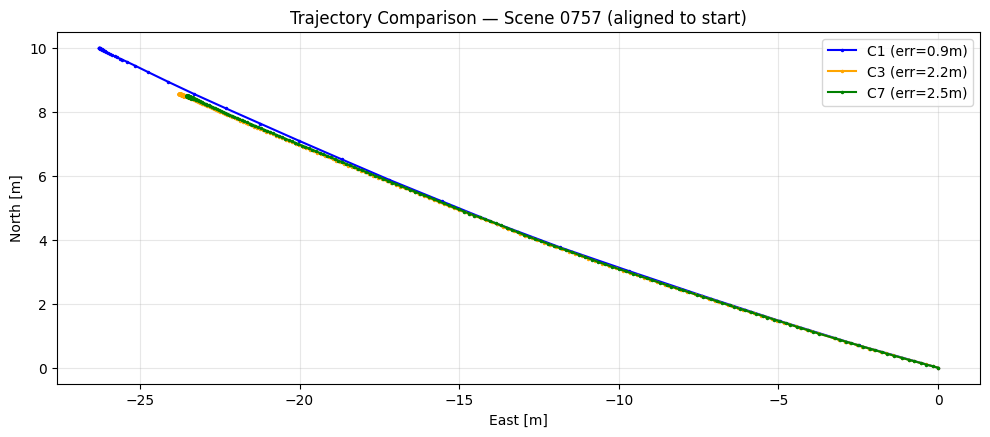

In [8]:
# Pick a scene and compare C1 vs C3 vs C7
scene_path = str(scenes[4])  # 0757
compare_cfgs = ['C1', 'C3', 'C7']
colors = {'C1': 'blue', 'C3': 'orange', 'C7': 'green'}

fig, ax = plt.subplots(figsize=(10, 8))

for cfg_name in compare_cfgs:
    cfg, init_gt = configs[cfg_name]
    try:
        r = nufuse.run_pipeline(scene_path, cfg, init_from_gt=init_gt)
        pos = np.array([p.translation for p in r.results.poses])
        # Normalize to common origin (C1 uses GT init → different start position)
        pos -= pos[0]
        ax.plot(pos[:, 0], pos[:, 1], '.-', color=colors[cfg_name],
                markersize=3, label=f"{cfg_name} (err={r.error.norm_error:.1f}m)")
    except Exception as e:
        print(f"{cfg_name} failed: {e}")

ax.set_xlabel('East [m]')
ax.set_ylabel('North [m]')
ax.set_title('Trajectory Comparison — Scene 0757 (aligned to start)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Pose Covariance Analysis

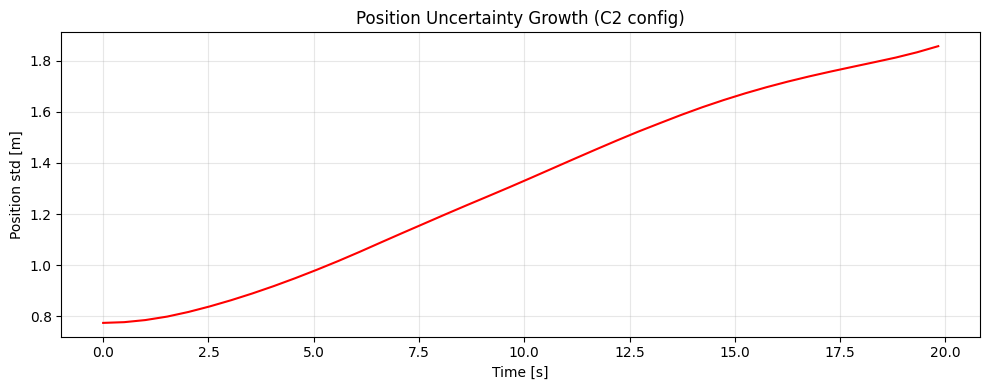

In [9]:
# Plot position uncertainty (trace of translation covariance) over time
cfg = nufuse.PipelineConfig()
cfg.enable_lidar = False
cfg.enable_radar = False
cfg.gps_max_measurements = 3

r = nufuse.run_pipeline(str(scenes[4]), cfg)

# Extract translation covariance trace (last 3 diagonal elements of 6x6)
cov_traces = [np.trace(p.covariance[3:, 3:]) for p in r.results.poses]
timestamps = np.array([p.stamp_ns for p in r.results.poses]) * 1e-9
timestamps -= timestamps[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(timestamps, np.sqrt(cov_traces), 'r-')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Position std [m]')
ax.set_title('Position Uncertainty Growth (C2 config)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Error Bar Chart

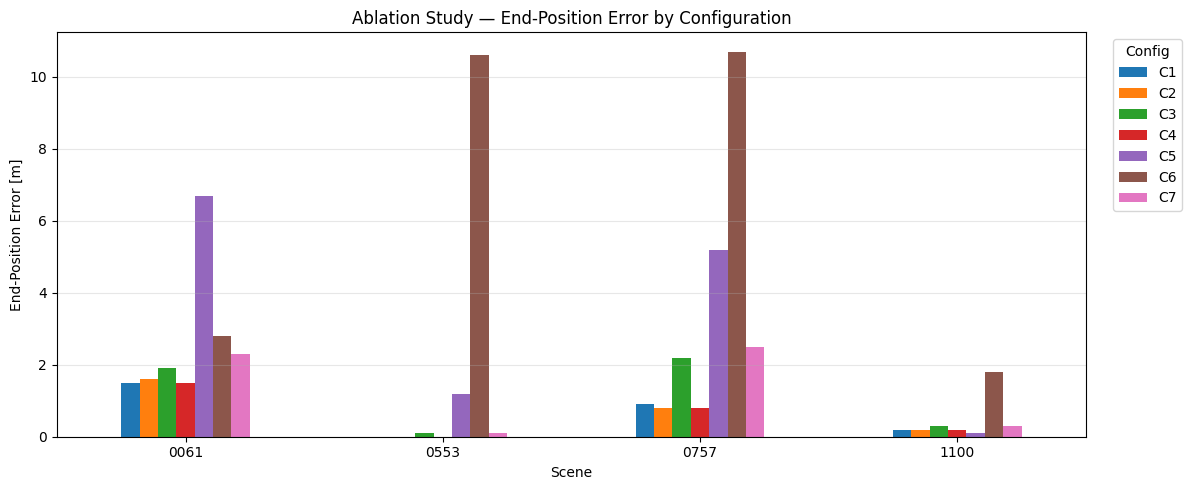

In [10]:
# Bar chart of errors across configs for a subset of scenes
subset_scenes = ['0061', '0553', '0757', '1100']
df_subset = df.loc[df.index.isin(subset_scenes)].dropna(axis=1)

ax = df_subset.plot(kind='bar', figsize=(12, 5), rot=0)
ax.set_xlabel('Scene')
ax.set_ylabel('End-Position Error [m]')
ax.set_title('Ablation Study — End-Position Error by Configuration')
ax.legend(title='Config', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. Robustification Comparison — GNC vs LM+Cauchy vs LM+Huber

Compare the effect of different outlier-rejection strategies on the full-sensor (C7) config.

In [11]:
# Compare robustification strategies on all scenes (full-sensor C7 config)
strategies = {}

# Strategy 1: GNC-LM (default — no robust kernel needed, GNC handles outliers)
cfg_gnc = nufuse.PipelineConfig()
cfg_gnc.gps_max_measurements = 3
cfg_gnc.optimizer = OptimizerType.GNC_LM
strategies['GNC-LM'] = cfg_gnc

# Strategy 2: LM + Cauchy kernel
cfg_cauchy = nufuse.PipelineConfig()
cfg_cauchy.gps_max_measurements = 3
cfg_cauchy.optimizer = OptimizerType.LM
cfg_cauchy.robust_kernel = RobustKernel.Cauchy
strategies['LM+Cauchy'] = cfg_cauchy

# Strategy 3: LM + Huber kernel (original behavior)
cfg_huber = nufuse.PipelineConfig()
cfg_huber.gps_max_measurements = 3
cfg_huber.optimizer = OptimizerType.LM
cfg_huber.robust_kernel = RobustKernel.Huber
strategies['LM+Huber'] = cfg_huber

# Run all strategies across all scenes
robust_results = {}
for scene_path in scenes:
    scene_id = scene_path.stem.split('-')[-1]
    robust_results[scene_id] = {}
    for strat_name, cfg in strategies.items():
        try:
            r = nufuse.run_pipeline(str(scene_path), cfg)
            robust_results[scene_id][strat_name] = round(r.error.norm_error, 2)
        except Exception as e:
            robust_results[scene_id][strat_name] = None
            print(f"  [{scene_id}/{strat_name}] Failed: {e}")
    print(f"  Scene {scene_id} done")

df_robust = pd.DataFrame.from_dict(robust_results, orient='index')
df_robust.index.name = 'Scene'

print("\n" + "="*60)
print("Full-Sensor (C7) End-Position Error [m] by Strategy")
print("="*60)
print(df_robust.to_markdown())

  Scene 0061 done
  Scene 0103 done
  Scene 0553 done
  Scene 0655 done
  Scene 0757 done
  Scene 0796 done
  Scene 0916 done
  Scene 1077 done
  Scene 1094 done
  Scene 1100 done

Full-Sensor (C7) End-Position Error [m] by Strategy
|   Scene |   GNC-LM |   LM+Cauchy |   LM+Huber |
|--------:|---------:|------------:|-----------:|
|    0061 |     3.76 |        2.35 |       2.58 |
|    0103 |     7.35 |        7.35 |       7.61 |
|    0553 |     0.06 |        0.06 |       0.34 |
|    0655 |    31.38 |       15.8  |      17.12 |
|    0757 |     3.03 |        2.45 |       2.36 |
|    0796 |    97.98 |       33.92 |      37.07 |
|    0916 |     7.22 |       10.66 |      10.07 |
|    1077 |    84.92 |       84.23 |      84.69 |
|    1094 |    47.21 |       14.48 |      15.48 |
|    1100 |     0.27 |        0.27 |       0.52 |


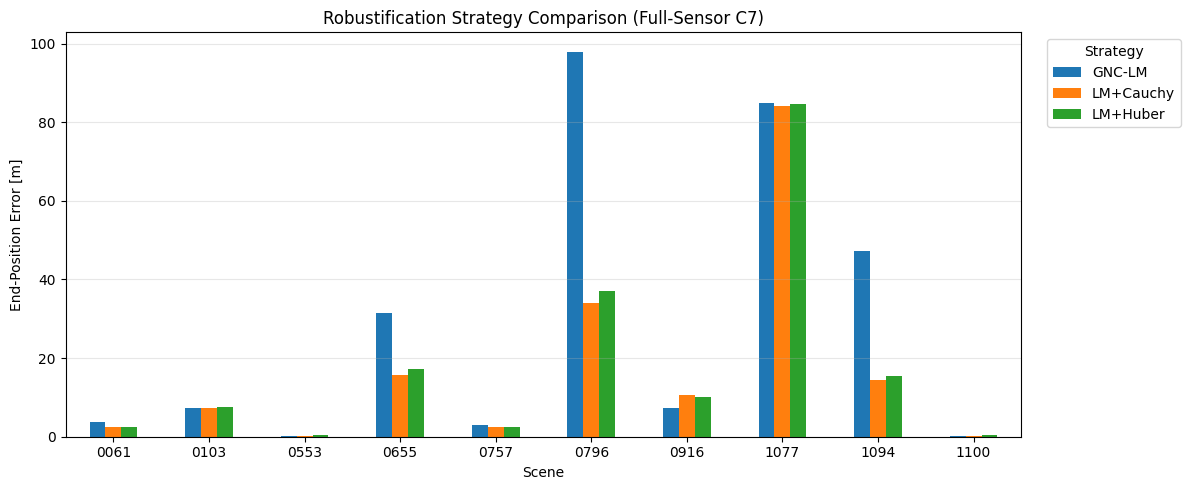


Mean error by strategy:
  GNC-LM      : 28.32 m
  LM+Cauchy   : 17.16 m
  LM+Huber    : 17.78 m


In [12]:
# Bar chart comparing robustification strategies
ax = df_robust.plot(kind='bar', figsize=(12, 5), rot=0)
ax.set_xlabel('Scene')
ax.set_ylabel('End-Position Error [m]')
ax.set_title('Robustification Strategy Comparison (Full-Sensor C7)')
ax.legend(title='Strategy', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print improvement summary
print("\nMean error by strategy:")
for col in df_robust.columns:
    mean_err = df_robust[col].dropna().mean()
    print(f"  {col:12s}: {mean_err:.2f} m")

## 8. LiDAR Quality Gating — Parameter Sensitivity

Demonstrate the effect of the new LiDAR quality gating parameters (min_inliers, max_registration_error, imu_consistency_threshold).

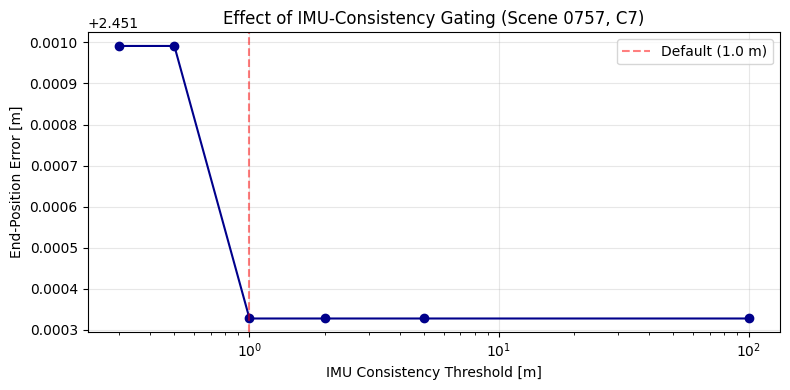


Threshold → Error:
    0.3 m → 2.452 m 
    0.5 m → 2.452 m 
    1.0 m → 2.451 m 
    2.0 m → 2.451 m 
    5.0 m → 2.451 m 
  100.0 m → 2.451 m (disabled)


In [13]:
# Sweep IMU-consistency threshold to see its effect on a single scene
scene_path = str(scenes[4])  # 0757
thresholds = [0.3, 0.5, 1.0, 2.0, 5.0, 100.0]  # 100 = effectively disabled

errors_by_threshold = {}
for thr in thresholds:
    cfg = nufuse.PipelineConfig()
    cfg.gps_max_measurements = 3
    cfg.lidar.imu_consistency_threshold = thr
    try:
        r = nufuse.run_pipeline(scene_path, cfg)
        errors_by_threshold[thr] = r.error.norm_error
    except Exception as e:
        errors_by_threshold[thr] = None
        print(f"  threshold={thr}: {e}")

fig, ax = plt.subplots(figsize=(8, 4))
valid = {k: v for k, v in errors_by_threshold.items() if v is not None}
ax.semilogx(list(valid.keys()), list(valid.values()), 'o-', color='darkblue')
ax.set_xlabel('IMU Consistency Threshold [m]')
ax.set_ylabel('End-Position Error [m]')
ax.set_title('Effect of IMU-Consistency Gating (Scene 0757, C7)')
ax.grid(True, alpha=0.3)
ax.axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Default (1.0 m)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nThreshold → Error:")
for thr, err in errors_by_threshold.items():
    label = "(disabled)" if thr >= 100 else ""
    print(f"  {thr:5.1f} m → {err:.3f} m {label}" if err else f"  {thr:5.1f} m → FAILED")

## 9. Loading Configuration from JSON

You can also load all parameters from `config/default.json` (or any custom JSON file) using `nufuse.load_config()`.

In [14]:
# Load full config from JSON file (includes all robustification defaults)
cfg_from_json = nufuse.load_config('../config/default.json')
print(f"Config from JSON: {cfg_from_json}")
print(f"  Optimizer:     {cfg_from_json.optimizer}")
print(f"  Robust kernel: {cfg_from_json.robust_kernel}")
print(f"  LiDAR gating:")
print(f"    min_inliers:              {cfg_from_json.lidar.min_inliers}")
print(f"    max_registration_error:   {cfg_from_json.lidar.max_registration_error}")
print(f"    max_translation_m:        {cfg_from_json.lidar.max_translation_m}")
print(f"    imu_consistency_threshold:{cfg_from_json.lidar.imu_consistency_threshold}")
print(f"  GNC params:")
print(f"    mu_step:           {cfg_from_json.gnc.mu_step}")
print(f"    relative_cost_tol: {cfg_from_json.gnc.relative_cost_tol}")
print(f"    weights_tol:       {cfg_from_json.gnc.weights_tol}")

# Run pipeline with JSON config
r = nufuse.run_pipeline(str(scenes[4]), cfg_from_json)
print(f"\nResult with JSON config: {r.error.norm_error:.3f} m")

Config from JSON: PipelineConfig(gps=1, lidar=1, radar=1, nhc=1, fwdvel=1, gps_max=0, optimizer=LM, kernel=Cauchy)
  Optimizer:     OptimizerType.LM
  Robust kernel: RobustKernel.Cauchy
  LiDAR gating:
    min_inliers:              0
    max_registration_error:   1000000000.0
    max_translation_m:        1000000000.0
    imu_consistency_threshold:0.0
  GNC params:
    mu_step:           1.4
    relative_cost_tol: 1e-05
    weights_tol:       0.0001

Result with JSON config: 0.154 m
